# 🧊 Projeto Fatorial 2³ com Replicações — Consenso entre LLMs

Fatores: **B = Domínio** (MovieReview/Books), **C = Consenso** (2×1 = exatamente 2
concordam / 3×0 = unânime), **D = Tamanho do texto** (corte na mediana por domínio).
Consenso construído reutilizando `ConsensusCalculator`. Projeto **2³ × 5 = 40 obs.**
Respostas: **F1 Macro** e **Acurácia**.

Estrutura: as premissas (§8) e cada análise (§9 F1, §10 Acurácia) trazem **duas
subseções — SEM transformação e COM transformação (logit)** — lado a lado.

> ⚠️ Erro experimental ínfimo (réplicas quase determinísticas): interprete pelo
> **tamanho do efeito (2q)** e pela **% de variação**. Os p-valores só são
> estatisticamente válidos na versão **logit** (premissas atendidas).


## 1) Setup e configuração

In [1]:
import os, sys, glob, json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from loguru import logger

ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.llm_annotation_system.consensus.consensus_calculator import ConsensusCalculator
from src.llm_annotation_system.consensus.consensus_evaluator import ConsensusEvaluator

logger.remove()
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"] = 110

MODELS = ["deepseek-r1-8b", "qwen3-8b", "llama3.1-8b"]
CONS_COLS = [f"{m}_consensus" for m in MODELS]
DATASETS = ["movie_review", "books"]   # B = -1 (movie), +1 (books)
N_REPS = 5
INVALID = -1
RESULTS_DIR = ROOT / "data" / "results"
FIG_DIR = ROOT / "src" / "notebooks" / "mq" / "figuras"
print("Raiz do projeto:", ROOT)

Raiz do projeto: C:\Users\gabri\Documents\GitHub\llm-annotation


## 2) Selecionar as 5 réplicas de cada dataset

As **5 últimas pastas** (ordem cronológica pelo nome) com `annotations.csv`.

In [2]:
def last_n_replication_folders(dataset, n=N_REPS):
    folders = sorted(
        d for d in glob.glob(str(RESULTS_DIR / dataset / "*") + os.sep)
        if os.path.exists(os.path.join(d, "annotations.csv"))
    )
    chosen = folders[-n:]
    if len(chosen) < n:
        raise ValueError(f"{dataset}: encontrei só {len(chosen)} pastas (esperado {n}).")
    return chosen

REPLICATION_FOLDERS = {ds: last_n_replication_folders(ds) for ds in DATASETS}
for ds, fs in REPLICATION_FOLDERS.items():
    print(f"\n== {ds} ==")
    for i, f in enumerate(fs, 1):
        print(f"  rep{i}: {os.path.basename(os.path.normpath(f))}")


== movie_review ==
  rep1: 2026-04-09_13-17-23
  rep2: 2026-05-17_14-44-16
  rep3: 2026-05-17_21-51-31
  rep4: 2026-05-18_06-14-02
  rep5: 2026-05-18_22-29-27

== books ==
  rep1: 2026-04-09_13-21-37
  rep2: 2026-05-20_21-44-17
  rep3: 2026-05-23_00-20-50
  rep4: 2026-05-24_20-47-50
  rep5: 2026-05-26_18-26-27


## 3) Consenso (partição por concordância) + corte por tamanho

`majority_vote` (threshold 0.8) por réplica; cada exemplo classificado pelo padrão
de concordância: **3×0** (`most_common_count==3`) ou **2×1** (`==2`). Limpeza:
descarta `ground_truth`/`resolved_annotation` inválidos e exige maioria
(`most_common_count>=2`). **D**: corte na mediana de `text_len` por domínio.

In [3]:
CONSENSOS = {"2x1": 2, "3x0": 3}

def get_categories(df):
    return sorted(int(v) for v in df["ground_truth"].unique() if v != INVALID)

def quality_metrics(y_true, y_pred):
    return {
        "accuracy":        accuracy_score(y_true, y_pred),
        "f1_macro":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

def consensus_universe(df_raw, categories, output_dir):
    calc = ConsensusCalculator(consensus_threshold=0.8, default_strategy="majority_vote")
    ev = ConsensusEvaluator(categories=categories, calculator=calc, output_dir=output_dir)
    sub = df_raw[["text_id", "text", "text_len", "ground_truth"] + CONS_COLS].copy()
    dfc = ev.compute_consensus(sub)
    dfc = dfc[(dfc["ground_truth"] != INVALID)
              & (dfc["resolved_annotation"] != INVALID)
              & (dfc["most_common_count"] >= 2)]
    return dfc

## 4) Métricas por célula (dataset × réplica × consenso × tamanho)

In [4]:
LEN_LEVELS = {"curto": -1, "longo": +1}

def split_by_length(df, mediana, nivel):
    return df[df["text_len"] <= mediana] if nivel == "curto" else df[df["text_len"] > mediana]

rows = []
for ds in DATASETS:
    for rep_idx, folder in enumerate(REPLICATION_FOLDERS[ds], 1):
        df_raw = pd.read_csv(os.path.join(folder, "annotations.csv"))
        categories = get_categories(df_raw)
        mediana = df_raw.loc[df_raw["ground_truth"] != INVALID, "text_len"].median()
        universe = consensus_universe(df_raw, categories, folder)
        total = len(universe)
        for consenso, need in CONSENSOS.items():
            uni_c = universe[universe["most_common_count"] == need]
            for nivel in LEN_LEVELS:
                cell = split_by_length(uni_c, mediana, nivel)
                m = quality_metrics(cell["ground_truth"].astype(int),
                                    cell["resolved_annotation"].astype(int))
                rows.append({"dataset": ds, "replica": rep_idx, "consenso": consenso,
                             "tamanho": nivel, "mediana_len": mediana,
                             "coverage": len(cell) / total if total else 0.0,
                             "n_total": total, "n_covered": len(cell), **m})

df_results = pd.DataFrame(rows)
print("Linhas:", len(df_results), "(esperado 2×2×2×5 = 40)")
chk = df_results.groupby(["dataset", "replica"]).agg(
    soma=("n_covered", "sum"), total=("n_total", "first")).reset_index()
print("Partição OK?", bool((chk["soma"] == chk["total"]).all()))
df_results

Linhas: 40 (esperado 2×2×2×5 = 40)
Partição OK? True


,dataset,replica,consenso,tamanho,mediana_len,coverage,n_total,n_covered,accuracy,f1_macro,precision_macro,recall_macro
0,movie_review,1,2x1,curto,112.0000,0.0494,10653,526,0.6350,0.6342,0.6350,0.6343
1,movie_review,1,2x1,longo,112.0000,0.0516,10653,550,0.6255,0.6251,0.6254,0.6257
2,movie_review,1,3x0,curto,112.0000,0.4539,10653,4835,0.9477,0.9476,0.9480,0.9475
3,movie_review,1,3x0,longo,112.0000,0.4451,10653,4742,0.9431,0.9431,0.9431,0.9432
4,movie_review,2,2x1,curto,112.0000,0.0481,10649,512,0.6387,0.6381,0.6382,0.6380
5,movie_review,2,2x1,longo,112.0000,0.0484,10649,515,0.6078,0.6061,0.6064,0.6074
6,movie_review,2,3x0,curto,112.0000,0.4549,10649,4844,0.9472,0.9471,0.9475,0.9469
7,movie_review,2,3x0,longo,112.0000,0.4487,10649,4778,0.9410,0.9410,0.9410,0.9411
8,movie_review,3,2x1,curto,112.0000,0.0502,10650,535,0.6430,0.6408,0.6432,0.6411
9,movie_review,3,2x1,longo,112.0000,0.0507,10650,540,0.6019,0.6012,0.6014,0.6018


### Tabela 1 — Resultados por célula

In [5]:
cols = ["dataset", "consenso", "tamanho", "replica", "f1_macro", "accuracy",
        "coverage", "n_covered", "n_total"]
df_results[cols].sort_values(["dataset", "consenso", "tamanho", "replica"]).reset_index(drop=True)

,dataset,consenso,tamanho,replica,f1_macro,accuracy,coverage,n_covered,n_total
0,books,2x1,curto,1,0.4904,0.5173,0.1282,4230,33005
1,books,2x1,curto,2,0.4752,0.5021,0.1305,4312,33034
2,books,2x1,curto,3,0.5006,0.5246,0.1307,4316,33029
3,books,2x1,curto,4,0.4781,0.5065,0.1282,4235,33029
4,books,2x1,curto,5,0.4783,0.5096,0.1308,4321,33036
5,books,2x1,longo,1,0.5515,0.5261,0.1201,3965,33005
6,books,2x1,longo,2,0.5537,0.5292,0.1206,3983,33034
7,books,2x1,longo,3,0.5356,0.5128,0.1222,4035,33029
8,books,2x1,longo,4,0.5356,0.5124,0.1185,3915,33029
9,books,2x1,longo,5,0.5581,0.5265,0.1213,4006,33036


## 5) Codificação do projeto fatorial 2³

B: movie=-1/books=+1 ; C: 2×1=-1/3×0=+1 ; D: curto=-1/longo=+1. Tratamento rotulado
pelas letras dos fatores em +1 (`(1)` se todos -1).

In [6]:
B_MAP = {"movie_review": -1, "books": +1}
C_MAP = {"2x1": -1, "3x0": +1}
D_MAP = {"curto": -1, "longo": +1}
df_results["B"] = df_results["dataset"].map(B_MAP)
df_results["C"] = df_results["consenso"].map(C_MAP)
df_results["D"] = df_results["tamanho"].map(D_MAP)

def treat_label(b, c, d):
    s = "".join(n for n, v in [("b", b), ("c", c), ("d", d)] if v == 1)
    return s if s else "(1)"

df_results["tratamento"] = [treat_label(b, c, d)
                            for b, c, d in zip(df_results["B"], df_results["C"], df_results["D"])]
df_results[["dataset", "consenso", "tamanho", "tratamento", "B", "C", "D",
            "f1_macro", "accuracy"]].head(40)

,dataset,consenso,tamanho,tratamento,B,C,D,f1_macro,accuracy
0,movie_review,2x1,curto,(1),-1,-1,-1,0.6342,0.6350
1,movie_review,2x1,longo,d,-1,-1,1,0.6251,0.6255
2,movie_review,3x0,curto,c,-1,1,-1,0.9476,0.9477
3,movie_review,3x0,longo,cd,-1,1,1,0.9431,0.9431
4,movie_review,2x1,curto,(1),-1,-1,-1,0.6381,0.6387
5,movie_review,2x1,longo,d,-1,-1,1,0.6061,0.6078
6,movie_review,3x0,curto,c,-1,1,-1,0.9471,0.9472
7,movie_review,3x0,longo,cd,-1,1,1,0.9410,0.9410
8,movie_review,2x1,curto,(1),-1,-1,-1,0.6408,0.6430
9,movie_review,2x1,longo,d,-1,-1,1,0.6012,0.6019


## 6) Função genérica de análise fatorial 2^k

$q = \dfrac{\sum (\text{contraste})\,y}{N}$ (N=40); **efeito**=2q; $SS=Nq^2$;
$SSE=SST-\sum SS$; $g.l._{erro}=2^k(r-1)=32$; $t=q/s_q$.

In [7]:
def factorial_2k_analysis(data, response, factors, r=N_REPS, alpha=0.05):
    d = data.copy()
    y = d[response].to_numpy(dtype=float)
    k = len(factors); N = (2 ** k) * r
    assert len(d) == N, f"Esperado {N} obs, obtidas {len(d)}"
    names, cols = [], {}
    for size in range(1, k + 1):
        for combo in combinations(factors, size):
            nm = "".join(combo); col = np.ones(N)
            for f in combo:
                col = col * d[f].to_numpy(dtype=float)
            names.append(nm); cols[nm] = col
    means = (d.groupby(["tratamento"] + factors)[response]
               .agg(media="mean", std="std", var="var", n="count").reset_index())
    SST = ((y - y.mean()) ** 2).sum(); df_err = (2 ** k) * (r - 1)
    qs, SS = {}, {}
    for nm in names:
        q = (cols[nm] * y).sum() / N; qs[nm] = q; SS[nm] = N * q ** 2
    SSE = SST - sum(SS.values()); s2e = SSE / df_err; s_q = np.sqrt(s2e / N)
    tcrit = stats.t.ppf(1 - alpha / 2, df_err)
    sig = pd.DataFrame([{
        "efeito": nm, "q": qs[nm], "efeito (2q)": 2 * qs[nm],
        "IC q low": qs[nm] - tcrit * s_q, "IC q high": qs[nm] + tcrit * s_q,
        "t": qs[nm] / s_q if s_q > 0 else np.nan,
        "p_value": 2 * stats.t.sf(abs(qs[nm] / s_q), df_err) if s_q > 0 else np.nan,
        "signif. (5%)": bool(2 * stats.t.sf(abs(qs[nm] / s_q), df_err) < alpha) if s_q > 0 else False,
        "SS": SS[nm], "% variação": 100 * SS[nm] / SST if SST > 0 else np.nan,
    } for nm in names])
    effects = sig[["efeito", "q", "efeito (2q)", "% variação"]].copy()
    ss_table = pd.DataFrame(
        [{"componente": nm, "SS": SS[nm], "g.l.": 1, "% variação": 100 * SS[nm] / SST} for nm in names]
        + [{"componente": "Erro", "SS": SSE, "g.l.": df_err, "% variação": 100 * SSE / SST},
           {"componente": "Total", "SS": SST, "g.l.": N - 1, "% variação": 100.0}])
    return {"response": response, "means": means, "effects": effects, "significance": sig,
            "ss_table": ss_table, "s2e": s2e, "s_q": s_q, "SSE": SSE, "SST": SST,
            "df_err": df_err, "t_crit": tcrit, "N": N}

FACTORS = ["B", "C", "D"]

## 7) Funções de gráfico (efeitos, interações e % de variação)

In [8]:
LAB = {"B": {-1: "MovieReview", +1: "Books"},
       "C": {-1: "Maioria (2×1)", +1: "Unanimidade (3×0)"},
       "D": {-1: "Curto", +1: "Longo"}}
FACTOR_NAME = {"B": "Domínio", "C": "Consenso", "D": "Tamanho"}
RED, GRAY, BLACK = "#C8102E", "#9A9A9A", "#1A1A1A"

def main_effect_plot(data, factor, response, ax):
    g = data.groupby(factor)[response].mean(); xs = sorted(g.index)
    ax.plot([LAB[factor][x] for x in xs], [g[x] for x in xs], "o-", lw=2, ms=9, color="#2c6fbb")
    for x in xs:
        ax.annotate(f"{g[x]:.4f}", (LAB[factor][x], g[x]), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=9)
    ax.set_title(f"Efeito principal — {FACTOR_NAME[factor]} ({factor})")
    ax.set_ylabel(f"Média de {response}"); ax.grid(alpha=0.3)

def interaction_plot(data, f1, f2, response, ax):
    colors = {-1: "#2c6fbb", +1: "#d1495b"}
    for lvl in (-1, +1):
        sub = data[data[f2] == lvl].groupby(f1)[response].mean(); xs = sorted(sub.index)
        ax.plot([LAB[f1][x] for x in xs], [sub[x] for x in xs], "o-", lw=2, ms=9,
                color=colors[lvl], label=f"{FACTOR_NAME[f2]}: {LAB[f2][lvl]}")
    ax.set_title(f"Interação {FACTOR_NAME[f1]} × {FACTOR_NAME[f2]} ({f1}{f2})")
    ax.set_ylabel(f"Média de {response}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

def plot_factorial(data, response):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, f in zip(axes[0], FACTORS):
        main_effect_plot(data, f, response, ax)
    for ax, (f1, f2) in zip(axes[1], [("B", "C"), ("B", "D"), ("C", "D")]):
        interaction_plot(data, f1, f2, response, ax)
    fig.suptitle(f"Projeto fatorial 2³ — resposta: {response}", fontsize=13)
    plt.tight_layout(); plt.show()

def plot_pct_variacao(res, titulo, fname=None):
    sig = res["significance"]; efs = sig["efeito"].tolist(); pvar = sig["% variação"].tolist()
    nome = {"B": "B\nDomínio", "C": "C\nConsenso", "D": "D\nTamanho"}
    labels = [nome.get(e, e) for e in efs]
    cores = [RED if e in ("B", "C", "D") else GRAY for e in efs]
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(range(len(efs)), pvar, color=cores, edgecolor=BLACK, linewidth=0.5)
    for i, v in enumerate(pvar):
        ax.annotate(f"{v:.1f}%", (i, v), textcoords="offset points", xytext=(0, 4),
                    ha="center", fontsize=9)
    ax.set_xticks(range(len(efs))); ax.set_xticklabels(labels)
    ax.set_ylabel("% da variação explicada"); ax.set_title(titulo, fontweight="bold")
    ax.set_ylim(0, max(pvar) * 1.12); plt.tight_layout()
    if fname:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / fname, bbox_inches="tight")
    plt.show()

## 8) Premissas do modelo — **verificadas antes da análise**

Resíduos $e_{ij}=y_{ij}-\bar{y}_{\text{tratamento}}$: normalidade (Shapiro + QQ +
histograma), homoscedasticidade (Levene/Bartlett + resíduos×ajustados),
independência (Durbin-Watson). Em **duas subseções: SEM e COM transformação
logit**.

In [9]:
def _residuos(data, response):
    d = data.copy()
    d["_fitted"] = d.groupby("tratamento")[response].transform("mean")
    d["_resid"] = d[response] - d["_fitted"]
    return d

def testar_premissas(data, response):
    d = _residuos(data, response); resid = d["_resid"].to_numpy()
    W, p_sw = stats.shapiro(resid)
    grupos = [g[response].to_numpy() for _, g in d.groupby("tratamento")]
    _, p_lev = stats.levene(*grupos, center="median")
    _, p_bar = stats.bartlett(*grupos)
    dw = np.sum(np.diff(resid) ** 2) / np.sum(resid ** 2)
    return {"resposta": response, "Shapiro_W": W, "Shapiro_p": p_sw, "normal_ok(5%)": p_sw >= 0.05,
            "Levene_p": p_lev, "Bartlett_p": p_bar, "homoced_ok(5%)": p_lev >= 0.05,
            "Durbin_Watson": dw}

def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

# colunas logit (usadas nas premissas e nas análises)
df_results["f1_logit"] = _logit(df_results["f1_macro"])
df_results["acc_logit"] = _logit(df_results["accuracy"])

def plot_residuos(data, response, axes):
    d = _residuos(data, response); resid = d["_resid"].to_numpy(); fitted = d["_fitted"].to_numpy()
    axes[0].hist(resid, bins=12, color="#C8102E", edgecolor="#1A1A1A")
    axes[0].set_title(f"Histograma resíduos — {response}"); axes[0].set_xlabel("resíduo")
    stats.probplot(resid, dist="norm", plot=axes[1]); axes[1].set_title(f"QQ-plot — {response}")
    axes[2].scatter(fitted, resid, color="#C8102E", edgecolor="#1A1A1A")
    axes[2].axhline(0, color="#1A1A1A", ls="--")
    axes[2].set_xlabel("ajustado (média do tratamento)"); axes[2].set_ylabel("resíduo")
    axes[2].set_title(f"Resíduos × ajustados — {response}")

### 8.1) Sem transformação (resposta original)

,resposta,Shapiro_W,Shapiro_p,normal_ok(5%),Levene_p,Bartlett_p,homoced_ok(5%),Durbin_Watson
0,f1_macro,0.9333,0.0207,False,0.0594,0.0000,True,1.8080
1,accuracy,0.9187,0.0070,False,0.0235,0.0000,False,1.7339


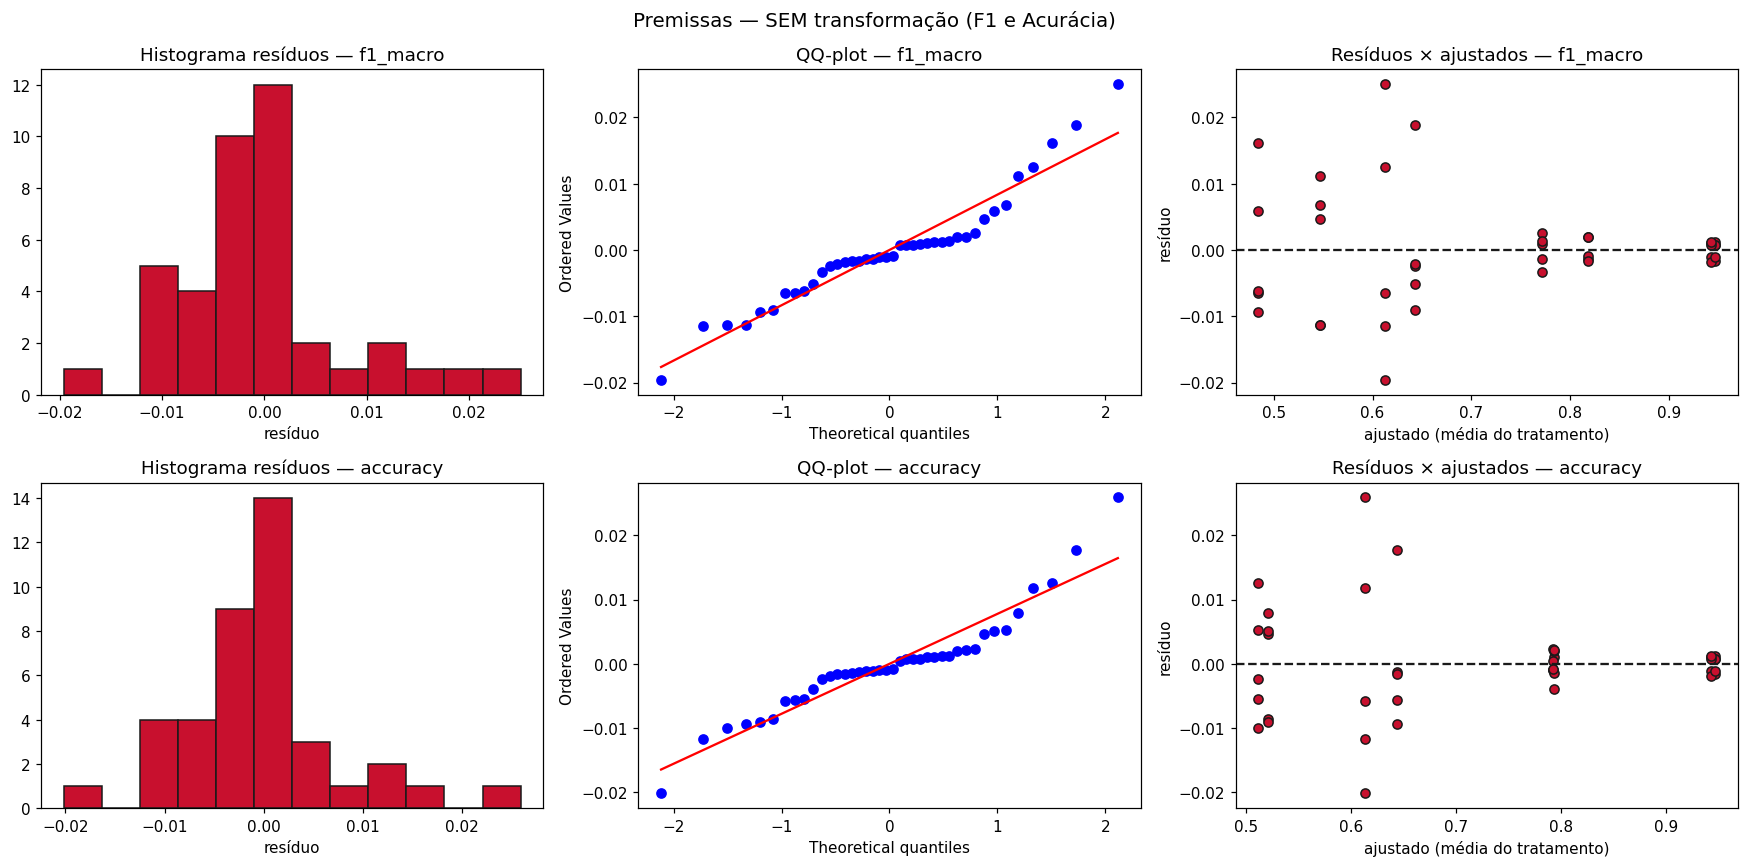

In [10]:
premissas = pd.DataFrame([testar_premissas(df_results, "f1_macro"),
                          testar_premissas(df_results, "accuracy")])
display(premissas)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_residuos(df_results, "f1_macro", axes[0])
plot_residuos(df_results, "accuracy", axes[1])
fig.suptitle("Premissas — SEM transformação (F1 e Acurácia)", fontsize=13)
plt.tight_layout(); plt.show()

### 8.2) Com transformação (logit)

,resposta,Shapiro_W,Shapiro_p,normal_ok(5%),Levene_p,Bartlett_p,homoced_ok(5%),Durbin_Watson
0,f1_logit,0.9633,0.2175,True,0.2870,0.0111,True,1.7590
1,acc_logit,0.9549,0.1114,True,0.1596,0.0056,True,1.7084


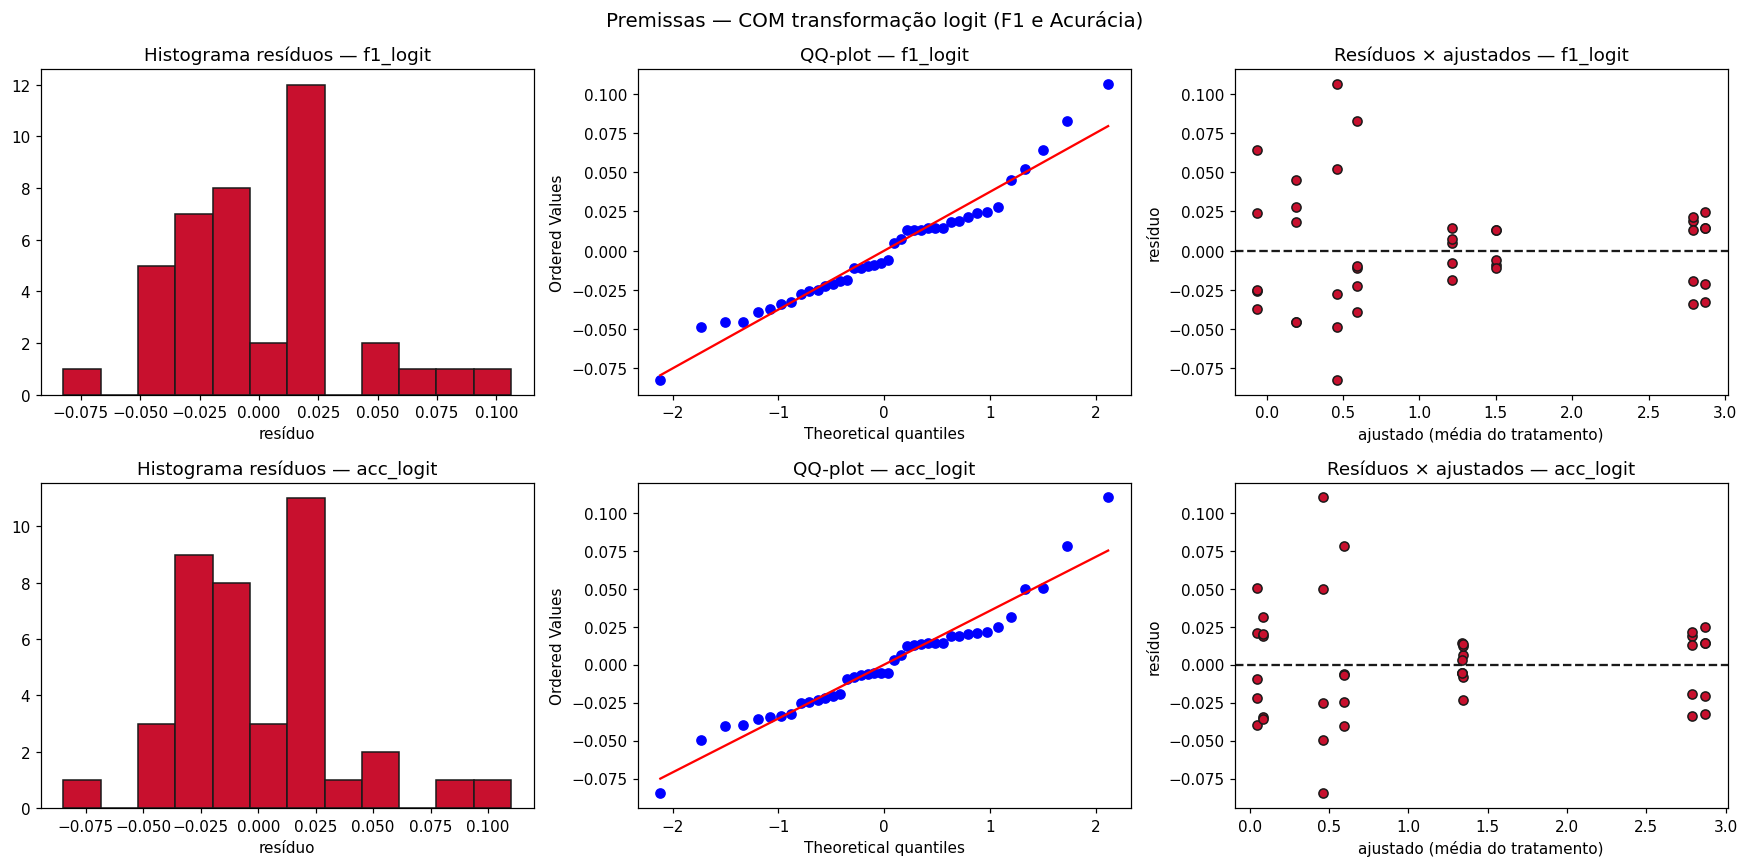

In [11]:
premissas_logit = pd.DataFrame([testar_premissas(df_results, "f1_logit"),
                                testar_premissas(df_results, "acc_logit")])
display(premissas_logit)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_residuos(df_results, "f1_logit", axes[0])
plot_residuos(df_results, "acc_logit", axes[1])
fig.suptitle("Premissas — COM transformação logit (F1 e Acurácia)", fontsize=13)
plt.tight_layout(); plt.show()

## 9) Análise fatorial — **F1 Macro**

### 9.1) Sem transformação (F1 original)

In [12]:
res_f1 = factorial_2k_analysis(df_results, "f1_macro", FACTORS)
print(f"s²_e = {res_f1['s2e']:.4e} | erro = {100*res_f1['SSE']/res_f1['SST']:.3f}% | "
      f"g.l. erro = {res_f1['df_err']}")
display(res_f1["effects"])
display(res_f1["significance"])
display(res_f1["ss_table"])

s²_e = 8.6516e-05 | erro = 0.256% | g.l. erro = 32


,efeito,q,efeito (2q),% variação
0,B,-0.0655,-0.1310,15.8927
1,C,0.1487,0.2975,81.9034
2,D,0.0092,0.0185,0.3161
3,BC,-0.0094,-0.0188,0.3272
4,BD,0.0180,0.0359,1.1952
5,CD,0.0013,0.0026,0.0062
6,BCD,-0.0053,-0.0105,0.1030


,efeito,q,efeito (2q),IC q low,IC q high,t,p_value,signif. (5%),SS,% variação
0,B,-0.0655,-0.1310,-0.0685,-0.0625,-44.5476,0.0000,True,0.1717,15.8927
1,C,0.1487,0.2975,0.1457,0.1517,101.1292,0.0000,True,0.8848,81.9034
2,D,0.0092,0.0185,0.0062,0.0122,6.2827,0.0000,True,0.0034,0.3161
3,BC,-0.0094,-0.0188,-0.0124,-0.0064,-6.3918,0.0000,True,0.0035,0.3272
4,BD,0.0180,0.0359,0.0150,0.0210,12.2166,0.0000,True,0.0129,1.1952
5,CD,0.0013,0.0026,-0.0017,0.0043,0.8767,0.3872,False,0.0001,0.0062
6,BCD,-0.0053,-0.0105,-0.0083,-0.0023,-3.5854,0.0011,True,0.0011,0.1030


,componente,SS,g.l.,% variação
0,B,0.1717,1,15.8927
1,C,0.8848,1,81.9034
2,D,0.0034,1,0.3161
3,BC,0.0035,1,0.3272
4,BD,0.0129,1,1.1952
5,CD,0.0001,1,0.0062
6,BCD,0.0011,1,0.1030
7,Erro,0.0028,32,0.2563
8,Total,1.0803,39,100.0000


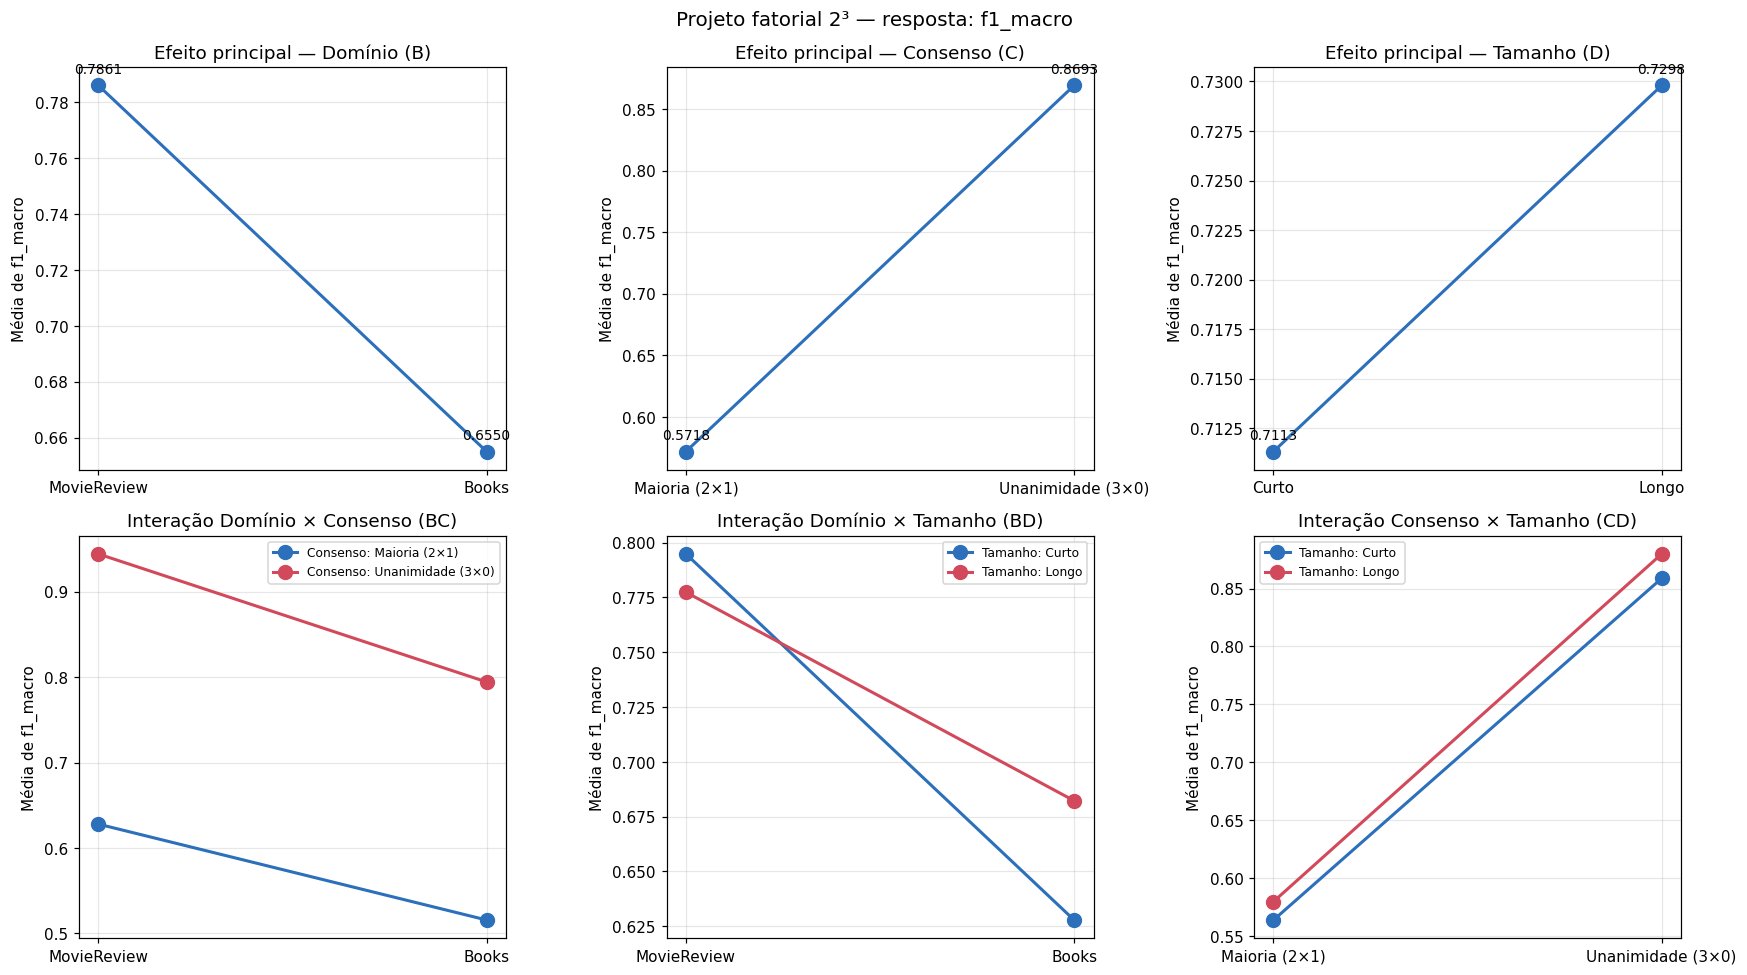

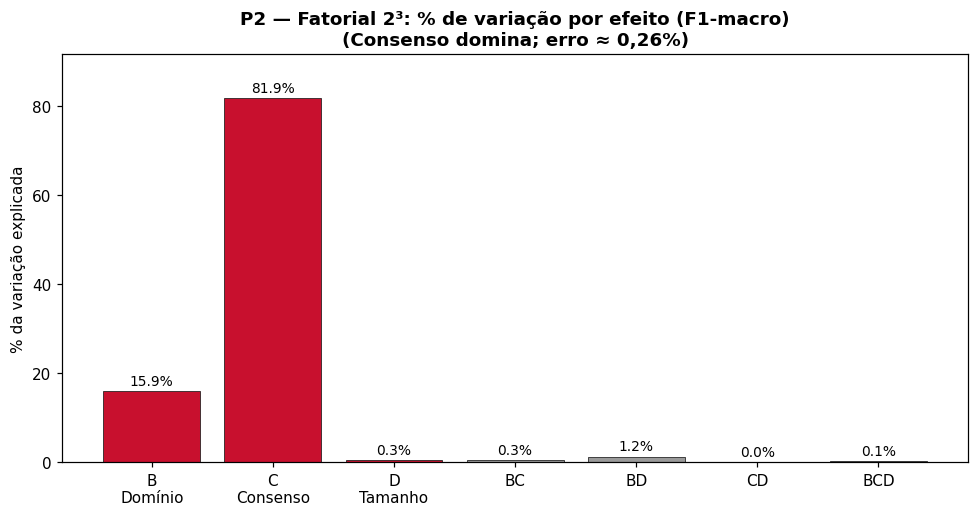

In [13]:
plot_factorial(df_results, "f1_macro")
plot_pct_variacao(res_f1,
    "P2 — Fatorial 2³: % de variação por efeito (F1-macro)\n(Consenso domina; erro ≈ 0,26%)",
    "P2_variacao_fatorial.png")

### 9.2) Com transformação (logit F1)

Premissas atendidas (§8.2) ⇒ **p-valores válidos**. Efeitos (2q) em **escala
logit**; comparação direta pela **% de variação** e pela significância.

In [14]:
res_f1_logit = factorial_2k_analysis(df_results, "f1_logit", FACTORS)
print(f"logit(F1): s²_e = {res_f1_logit['s2e']:.4e} | "
      f"erro = {100*res_f1_logit['SSE']/res_f1_logit['SST']:.3f}%")
display(res_f1_logit["significance"][["efeito", "efeito (2q)", "p_value", "signif. (5%)", "% variação"]])
_cmp = res_f1["effects"][["efeito", "% variação"]].rename(columns={"% variação": "%var_F1_original"})
_cmp["%var_logit(F1)"] = res_f1_logit["effects"]["% variação"].values
print("Comparação % de variação (F1 original × logit):")
display(_cmp.round(2))

logit(F1): s²_e = 1.6893e-03 | erro = 0.121%


,efeito,efeito (2q),p_value,signif. (5%),% variação
0,B,-0.9667,0.0000,True,20.8738
1,C,1.7998,0.0000,True,72.3613
2,D,0.0807,0.0000,True,0.1453
3,BC,-0.5054,0.0000,True,5.7068
4,BD,0.1871,0.0000,True,0.7820
5,CD,0.0209,0.1177,False,0.0098
6,BCD,-0.0033,0.7997,False,0.0002


Comparação % de variação (F1 original × logit):


,efeito,%var_F1_original,%var_logit(F1)
0,B,15.8900,20.8700
1,C,81.9000,72.3600
2,D,0.3200,0.1500
3,BC,0.3300,5.7100
4,BD,1.2000,0.7800
5,CD,0.0100,0.0100
6,BCD,0.1000,0.0000


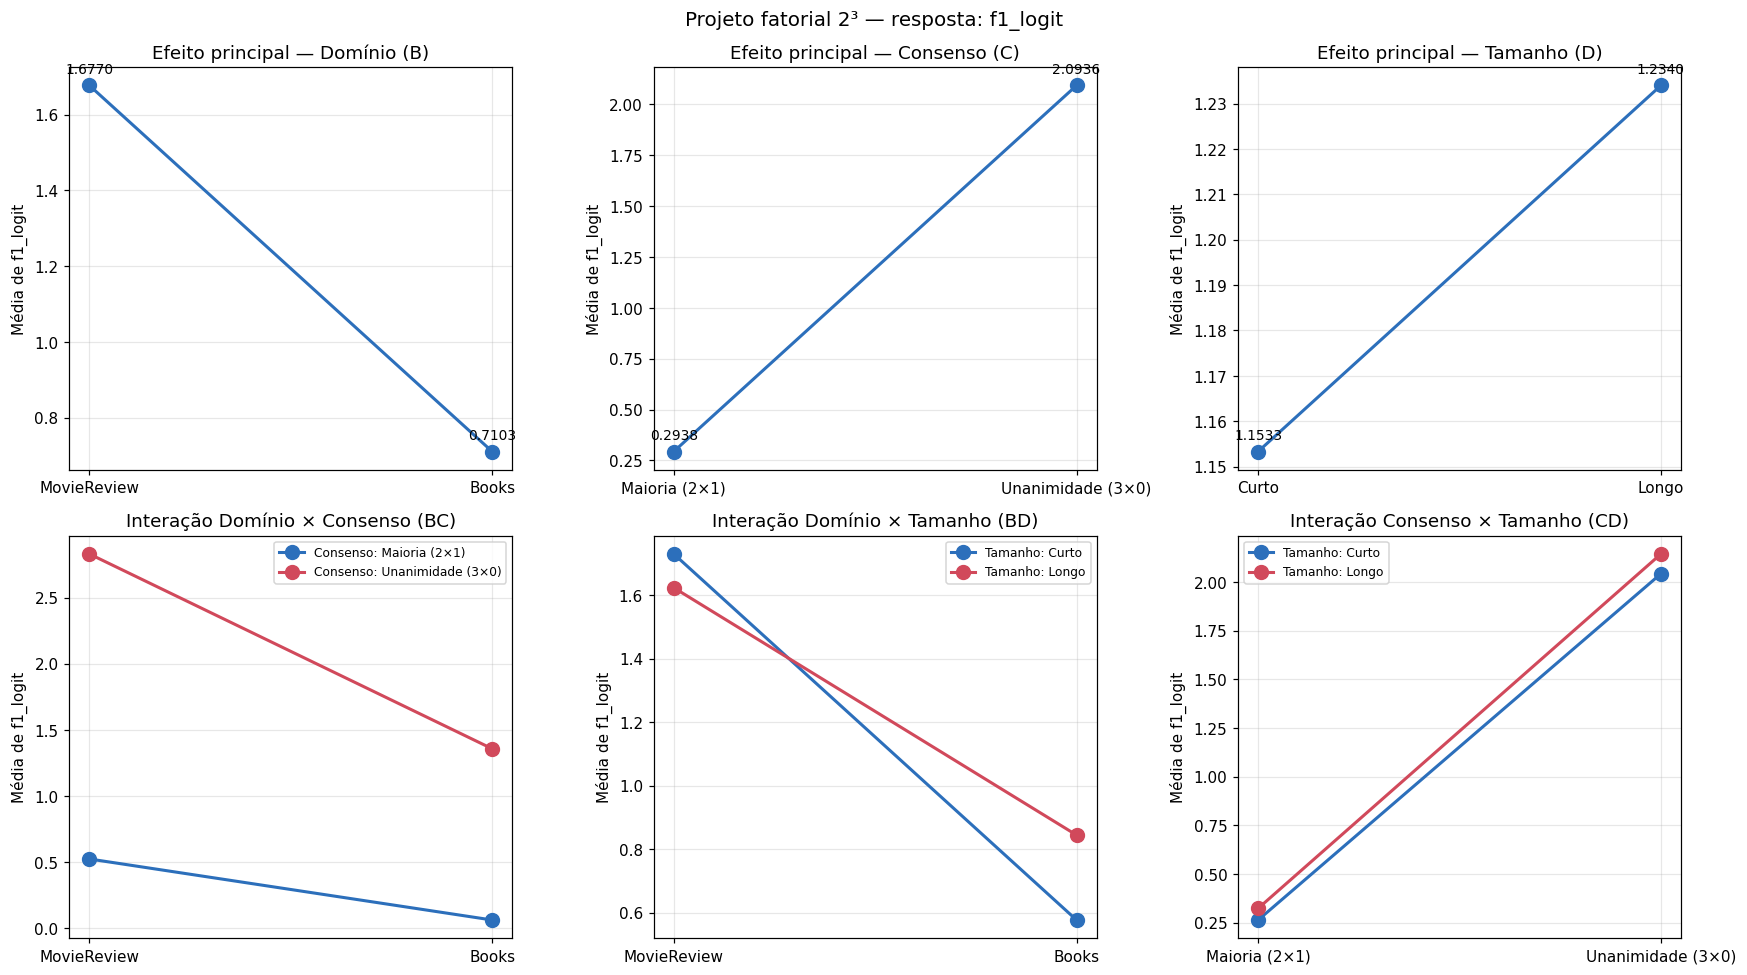

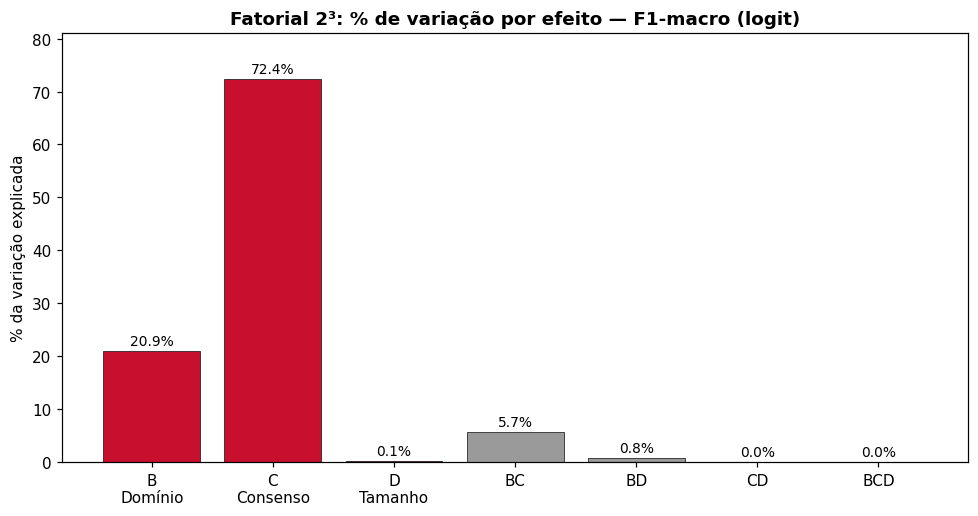

In [15]:
plot_factorial(df_results, "f1_logit")
plot_pct_variacao(res_f1_logit,
    "Fatorial 2³: % de variação por efeito — F1-macro (logit)", "variacao_f1logit.png")

## 10) Análise fatorial — **Acurácia**

### 10.1) Sem transformação (Acurácia original)

In [16]:
res_acc = factorial_2k_analysis(df_results, "accuracy", FACTORS)
print(f"s²_e = {res_acc['s2e']:.4e} | erro = {100*res_acc['SSE']/res_acc['SST']:.3f}% | "
      f"g.l. erro = {res_acc['df_err']}")
display(res_acc["effects"])
display(res_acc["significance"])
display(res_acc["ss_table"])

s²_e = 7.6857e-05 | erro = 0.233% | g.l. erro = 32


,efeito,q,efeito (2q),% variação
0,B,-0.0660,-0.1319,16.4651
1,C,0.1478,0.2956,82.6878
2,D,-0.0033,-0.0066,0.0417
3,BC,-0.0098,-0.0197,0.3661
4,BD,0.0054,0.0109,0.1122
5,CD,0.0020,0.0040,0.0152
6,BCD,-0.0046,-0.0092,0.0792


,efeito,q,efeito (2q),IC q low,IC q high,t,p_value,signif. (5%),SS,% variação
0,B,-0.0660,-0.1319,-0.0688,-0.0631,-47.5825,0.0000,True,0.1740,16.4651
1,C,0.1478,0.2956,0.1450,0.1506,106.6317,0.0000,True,0.8739,82.6878
2,D,-0.0033,-0.0066,-0.0061,-0.0005,-2.3953,0.0226,True,0.0004,0.0417
3,BC,-0.0098,-0.0197,-0.0127,-0.0070,-7.0949,0.0000,True,0.0039,0.3661
4,BD,0.0054,0.0109,0.0026,0.0083,3.9273,0.0004,True,0.0012,0.1122
5,CD,0.0020,0.0040,-0.0008,0.0048,1.4450,0.1582,False,0.0002,0.0152
6,BCD,-0.0046,-0.0092,-0.0074,-0.0018,-3.3009,0.0024,True,0.0008,0.0792


,componente,SS,g.l.,% variação
0,B,0.1740,1,16.4651
1,C,0.8739,1,82.6878
2,D,0.0004,1,0.0417
3,BC,0.0039,1,0.3661
4,BD,0.0012,1,0.1122
5,CD,0.0002,1,0.0152
6,BCD,0.0008,1,0.0792
7,Erro,0.0025,32,0.2327
8,Total,1.0569,39,100.0000


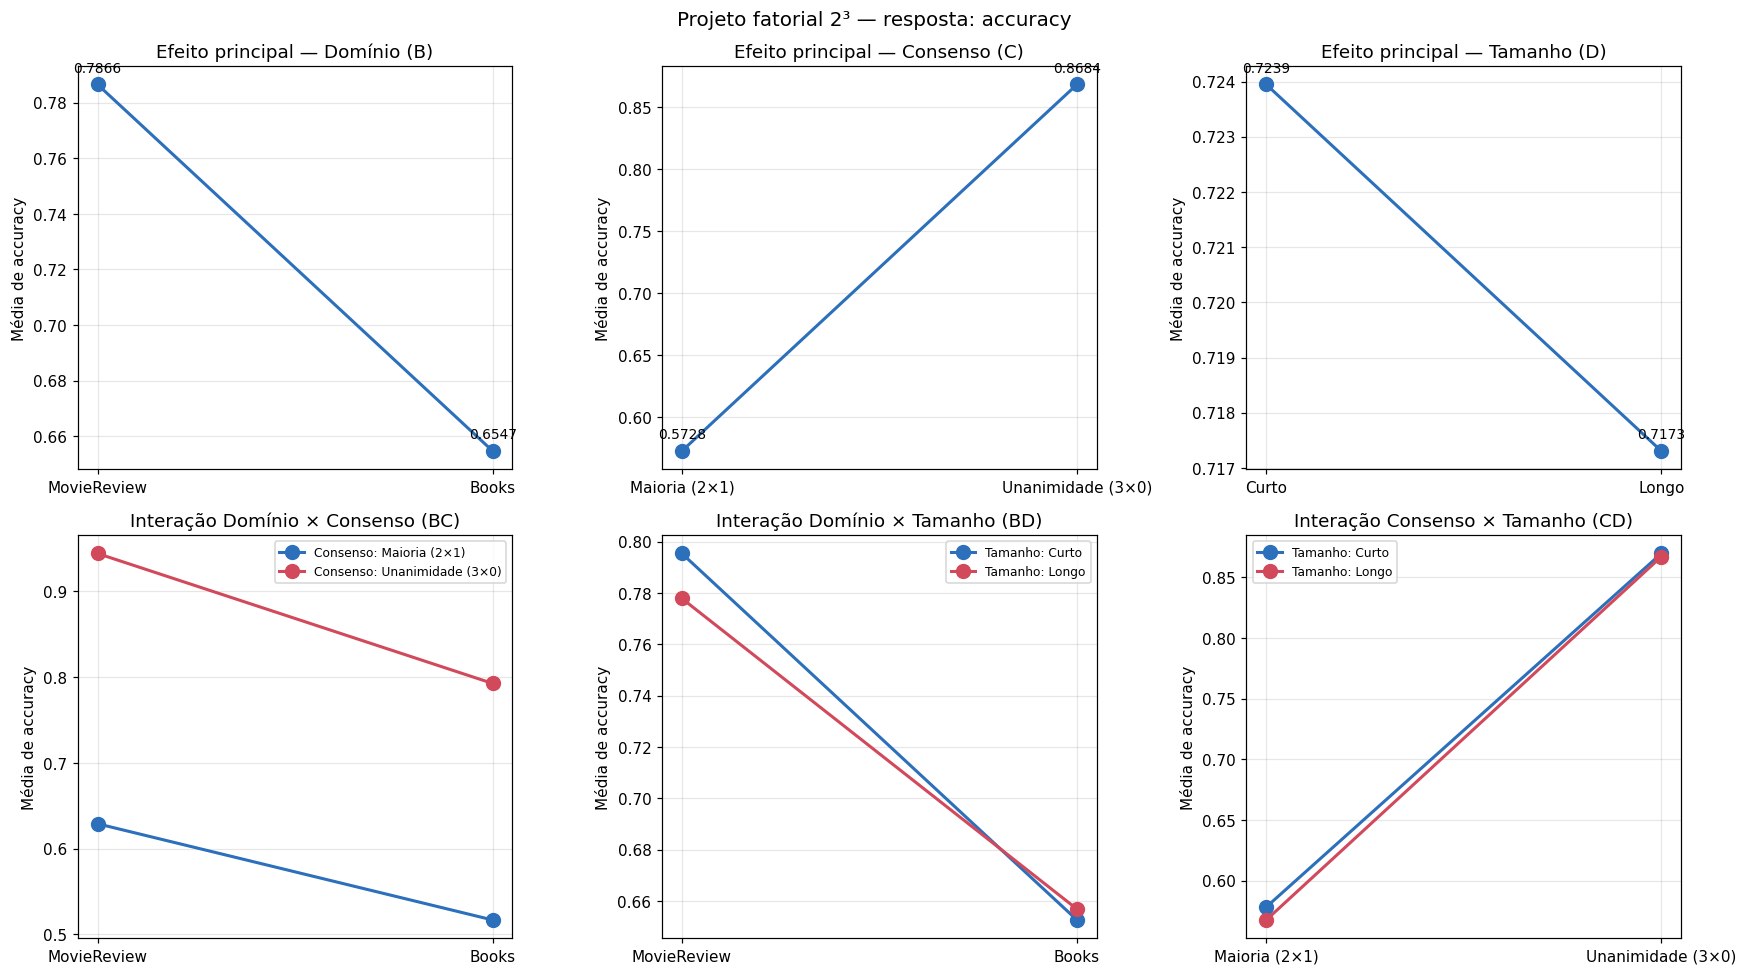

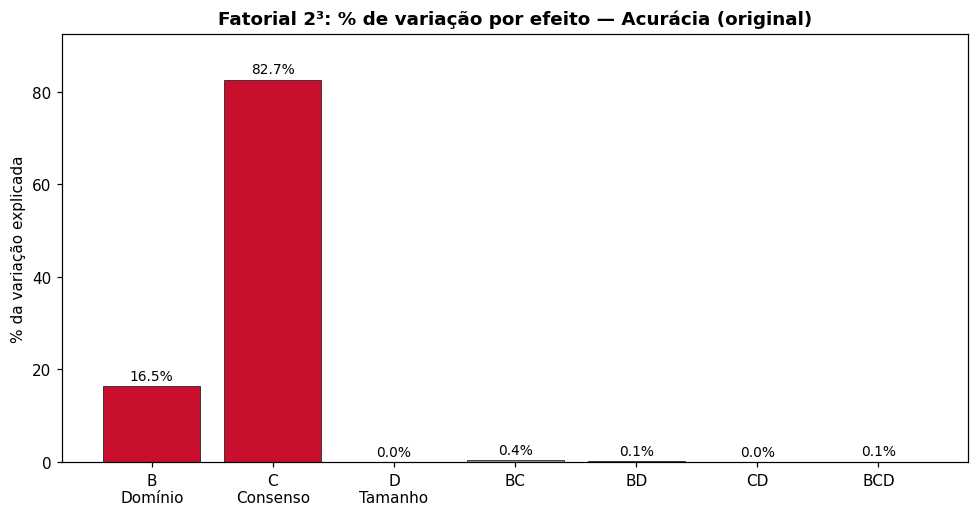

In [17]:
plot_factorial(df_results, "accuracy")
plot_pct_variacao(res_acc,
    "Fatorial 2³: % de variação por efeito — Acurácia (original)", "variacao_acc.png")

### 10.2) Com transformação (logit Acurácia)

In [18]:
res_acc_logit = factorial_2k_analysis(df_results, "acc_logit", FACTORS)
print(f"logit(Acc): s²_e = {res_acc_logit['s2e']:.4e} | "
      f"erro = {100*res_acc_logit['SSE']/res_acc_logit['SST']:.3f}%")
display(res_acc_logit["significance"][["efeito", "efeito (2q)", "p_value", "signif. (5%)", "% variação"]])
_cmpa = res_acc["effects"][["efeito", "% variação"]].rename(columns={"% variação": "%var_Acc_original"})
_cmpa["%var_logit(Acc)"] = res_acc_logit["effects"]["% variação"].values
print("Comparação % de variação (Acurácia original × logit):")
display(_cmpa.round(2))

logit(Acc): s²_e = 1.5324e-03 | erro = 0.111%


,efeito,efeito (2q),p_value,signif. (5%),% variação
0,B,-0.9754,0.0000,True,21.5136
1,C,1.7878,0.0000,True,72.2660
2,D,-0.0455,0.0009,True,0.0469
3,BC,-0.5136,0.0000,True,5.9650
4,BD,0.0616,0.0000,True,0.0858
5,CD,0.0013,0.9194,False,0.0000
6,BCD,-0.0228,0.0745,False,0.0118


Comparação % de variação (Acurácia original × logit):


,efeito,%var_Acc_original,%var_logit(Acc)
0,B,16.4700,21.5100
1,C,82.6900,72.2700
2,D,0.0400,0.0500
3,BC,0.3700,5.9600
4,BD,0.1100,0.0900
5,CD,0.0200,0.0000
6,BCD,0.0800,0.0100


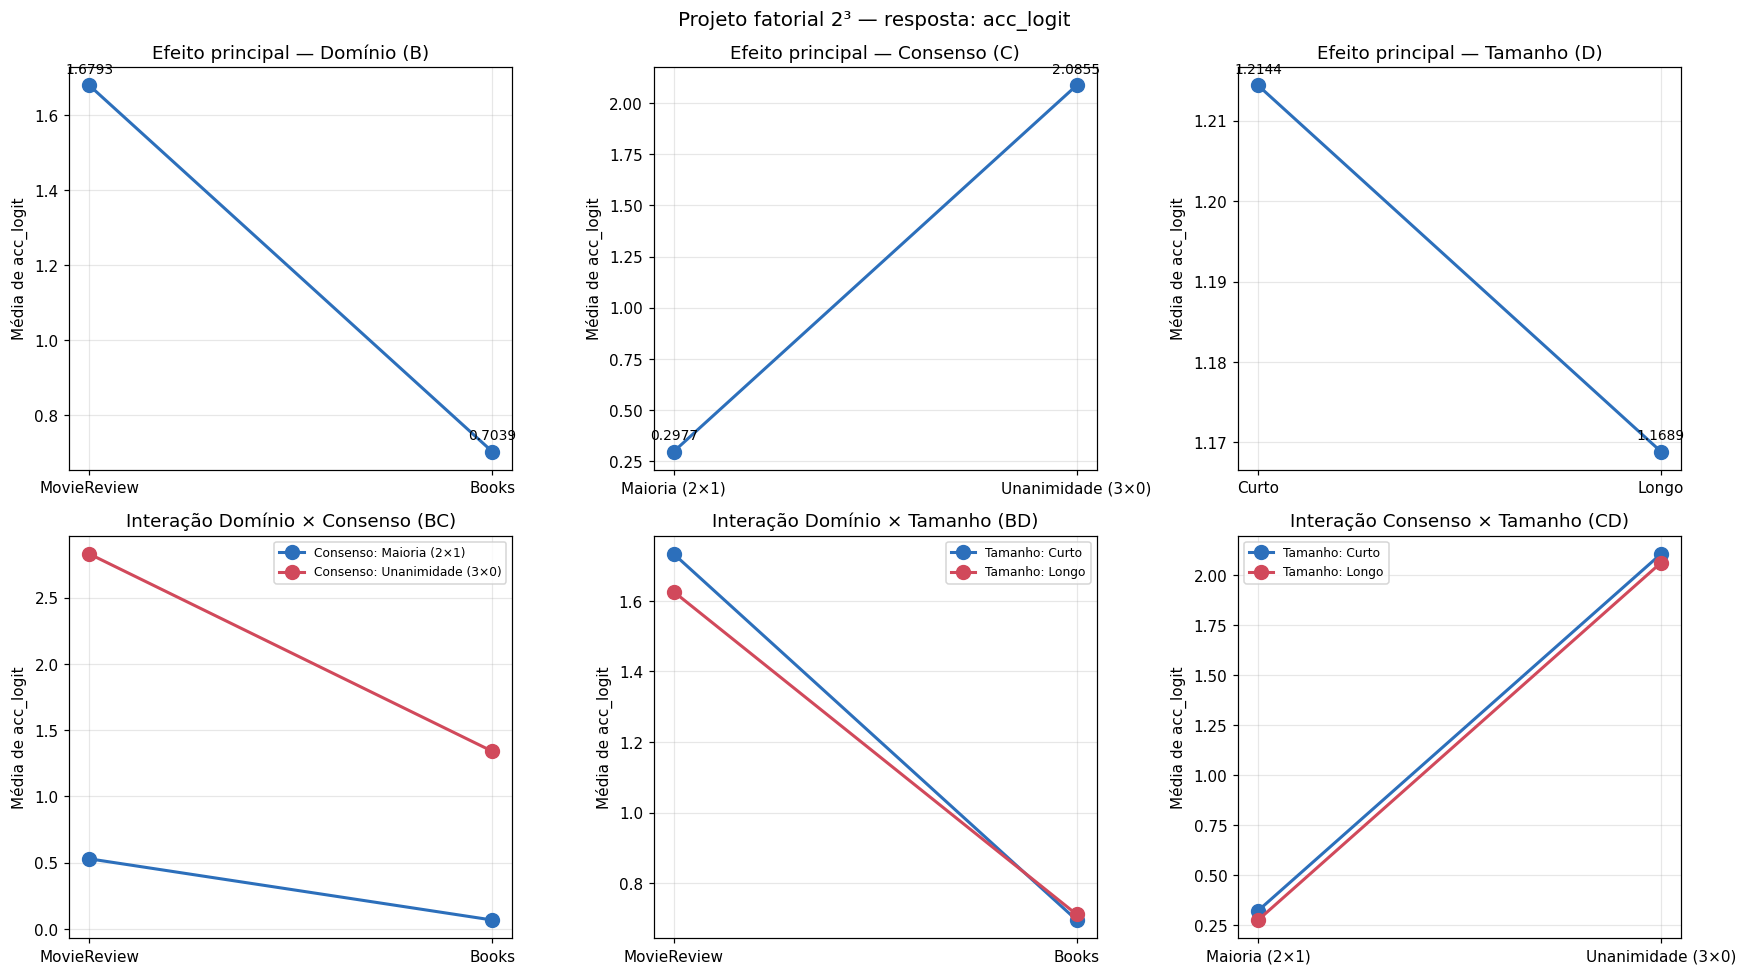

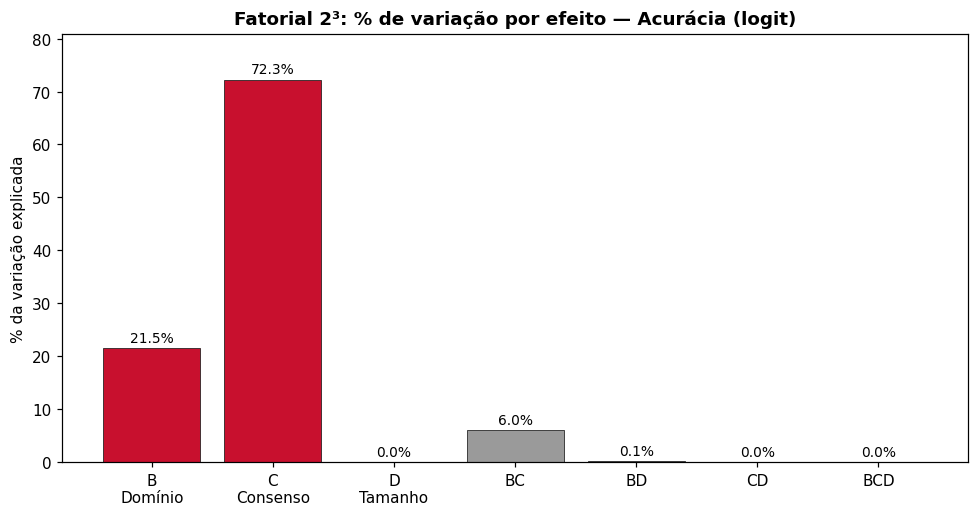

In [19]:
plot_factorial(df_results, "acc_logit")
plot_pct_variacao(res_acc_logit,
    "Fatorial 2³: % de variação por efeito — Acurácia (logit)", "variacao_acclogit.png")

## 11) Resumo / interpretação

- **Consenso (C)** domina (~72% em logit), **Domínio (B)** em segundo (~21%);
  interação **BC** relevante (~6% em logit). Tamanho (D) e demais interações
  pequenos; **CD/BCD não-significativos** na escala logit.
- **Premissas (§8):** o F1/acurácia originais violam normalidade e
  homoscedasticidade (funil); **logit corrige ambas** → a inferência válida é a das
  subseções **9.2 / 10.2**.

In [20]:
def resumo(res, titulo):
    err = 100 * res["SSE"] / res["SST"]
    print(f"=== {titulo} ===")
    print(res["significance"][["efeito", "efeito (2q)", "p_value", "signif. (5%)", "% variação"]].to_string(index=False))
    print(f"erro experimental: s²_e={res['s2e']:.3e} | {err:.4f}% da variação\n")

resumo(res_f1, "F1 (original)"); resumo(res_f1_logit, "F1 (logit)")
resumo(res_acc, "Acurácia (original)"); resumo(res_acc_logit, "Acurácia (logit)")

=== F1 (original) ===
efeito  efeito (2q)  p_value  signif. (5%)  % variação
     B      -0.1310   0.0000          True     15.8927
     C       0.2975   0.0000          True     81.9034
     D       0.0185   0.0000          True      0.3161
    BC      -0.0188   0.0000          True      0.3272
    BD       0.0359   0.0000          True      1.1952
    CD       0.0026   0.3872         False      0.0062
   BCD      -0.0105   0.0011          True      0.1030
erro experimental: s²_e=8.652e-05 | 0.2563% da variação

=== F1 (logit) ===
efeito  efeito (2q)  p_value  signif. (5%)  % variação
     B      -0.9667   0.0000          True     20.8738
     C       1.7998   0.0000          True     72.3613
     D       0.0807   0.0000          True      0.1453
    BC      -0.5054   0.0000          True      5.7068
    BD       0.1871   0.0000          True      0.7820
    CD       0.0209   0.1177         False      0.0098
   BCD      -0.0033   0.7997         False      0.0002
erro experimental: s²_

## 12) Exportar análises (.json) — `data/results/mq/fatorial_2x2x2`

In [21]:
EXPORT_DIR = ROOT / "data" / "results" / "mq" / "fatorial_2x2x2"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def _j(o):
    if isinstance(o, pd.DataFrame): return o.to_dict(orient="records")
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.bool_,)): return bool(o)
    if isinstance(o, dict): return {k: _j(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_j(v) for v in o]
    return o

payload = {
    "design": "2^3 (B=domínio, C=consenso, D=tamanho)",
    "n_replicas": N_REPS,
    "premissas": {"sem_transformacao": _j(premissas), "com_logit": _j(premissas_logit)},
    "resultados_por_celula": _j(df_results),
    "analise": {
        "f1_macro": _j(res_f1), "f1_logit": _j(res_f1_logit),
        "accuracy": _j(res_acc), "acc_logit": _j(res_acc_logit),
    },
}
with open(EXPORT_DIR / "analise_fatorial_2x2x2.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
with open(EXPORT_DIR / "resultados_por_celula.json", "w", encoding="utf-8") as f:
    json.dump(_j(df_results), f, ensure_ascii=False, indent=2)
print("✓ Salvo em:", EXPORT_DIR)

✓ Salvo em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\mq\fatorial_2x2x2
